### General Imports:


In [ ]:
import os
import gymnasium as gym
from stable_baselines3.ppo import PPO, MlpPolicy
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy.common.allocators import sap_ff
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PolynomialFeatures

logging.getLogger("tensorflow").setLevel(logging.FATAL)

In [ ]:
# FILES AND DIRECTORIES:
__file__ = "[DAGGER] HEURISTIC_LGR.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 200000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
    allocator=sap_ff(3),
)

env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)
eval_env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir + "eval_env")

mArgs = dict(
    learning_rate=0.0005,
    gamma=0.9,
)
# expert = PPO(MlpPolicy, env, verbose=0, seed=3, **mArgs)
# train_model = expert.learn(total_timesteps=1)

# best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
# expert = PPO.load(best_model_dir)

In [50]:
from sklearn.linear_model import RidgeClassifier
from sklearn.utils.class_weight import compute_class_weight
from netsim.explainable.common.rollout import generate_trajectories, flatten_trajectories
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from netsim.netSimPy.common.heuristic_models import FirstFitModel

FEATURE_IDXS = [28, 41]
USE_FEATURE_SUBSET = True
SAMPLE_TIMESTEPS_FOR_WEIGHTS = 400000
EXTRA_WEIGHT_CLASS0 = 3.5  # multiplica el peso de la clase 0

n_rounds = 1
beta_func = linear_beta(1, 0, n_rounds)

expert = FirstFitModel()

# pesos de clases a partir de muestras del experto
traj_sample = generate_trajectories(SAMPLE_TIMESTEPS_FOR_WEIGHTS, expert, env)
_, acts_sample, _ = flatten_trajectories(traj_sample)
classes = np.unique(acts_sample)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=acts_sample)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
if 0 in class_weight:
    class_weight[0] *= EXTRA_WEIGHT_CLASS0
# resetea env después de muestrear
options = {"lambda": M_LAMBDA, "hard_reset": True}

pipeline_steps = []
if USE_FEATURE_SUBSET:
    selector = FunctionTransformer(
        lambda X: np.asarray(X)[:, FEATURE_IDXS], validate=False
    )
    pipeline_steps.append(("select", selector))

# pipeline_steps.append(("poly", PolynomialFeatures(degree=1, include_bias=False)))
pipeline_steps.append(
    (
        "clf",
        # RidgeClassifier(class_weight=class_weight),
        RidgeClassifier(
            class_weight=class_weight,
        ),
    )
)

student = Pipeline(pipeline_steps)

dagger_trainer = Dagger(expert, student, env, beta_func)
model = dagger_trainer.train(n_rounds, timesteps_by_round=400000, n_evaluations=100)

#
#

Starting round 1
Sampling new trajectories for round: {1} 
0.93 [[88  7]
 [ 0  5]]


### features importance


           0
28  0.006136
41 -0.000487


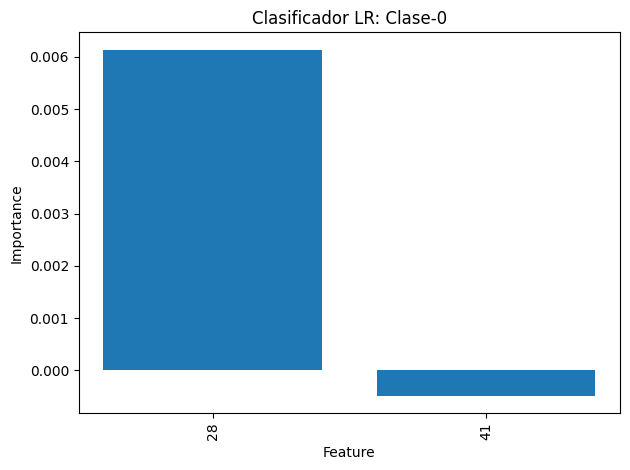

           0
28 -0.002984
41  0.003677


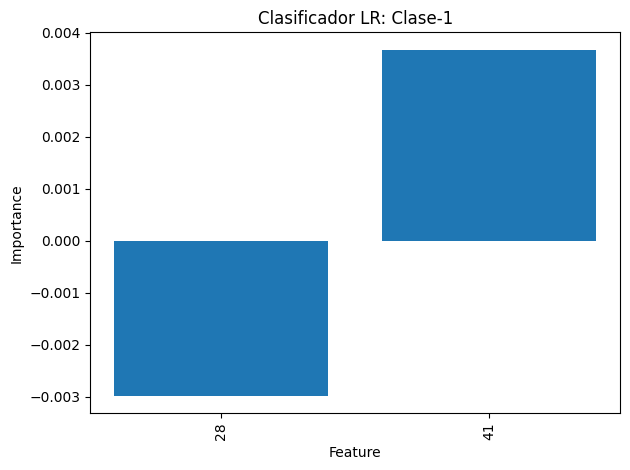

           0
28 -0.003151
41 -0.003191


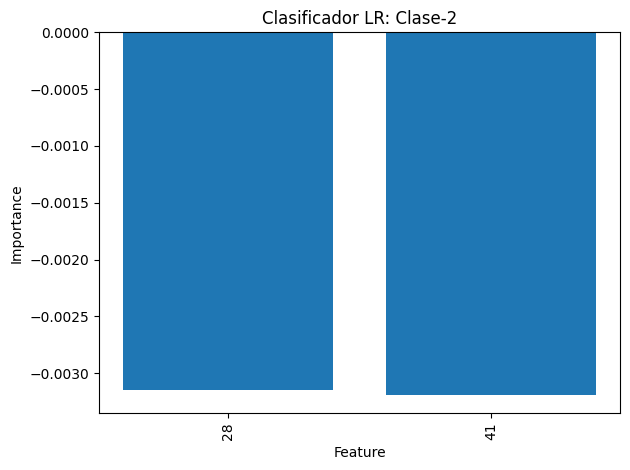

In [55]:
import pandas as pd

lr_model = student.named_steps.get("clf", student)
poly = student.named_steps.get("poly") if hasattr(student, "named_steps") else None

if poly is not None:
    base_features = [
        f"f{idx}"
        for idx in (FEATURE_IDXS if USE_FEATURE_SUBSET else range(poly.n_features_in_))
    ]
    feature_labels = poly.get_feature_names_out(base_features)
else:
    feature_labels = (
        FEATURE_IDXS if USE_FEATURE_SUBSET else list(range(lr_model.n_features_in_))
    )

for i, importances_sk in enumerate(lr_model.coef_):
    importance = pd.DataFrame(importances_sk, index=feature_labels)
    print(importance)
    plt.figure()
    plt.bar(range(len(importances_sk)), importances_sk)
    plt.xticks(range(len(importances_sk)), feature_labels, rotation=90)
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.title(f"Clasificador LR: Clase-{i}")
    plt.tight_layout()
    plt.show()